# Requirement Setup

In [6]:
!pip install prophet
!pip install scikit-learn
!pip install tensorflow
!pip install setuptools

In [7]:
%pip install keras-tuner

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import numpy as np
import time
import matplotlib.pyplot as plt
from datetime import datetime
from prophet.serialize import model_to_json, model_from_json

Note: you may need to restart the kernel to use updated packages.


Enable / Disable Hyperparameter Tuning

In [8]:
HYPERPARAMETER_TUNING = False

In [9]:
np.random.seed(42)
tf.random.set_seed(42)

# Data Loading

In [10]:
raw_df = pd.read_csv('../data/data.csv', parse_dates=['timestamp'])
primary_service = raw_df['service_id'].mode()[0]
df_pods = raw_df[raw_df['service_id'] == primary_service].copy()
df_pods = df_pods.sort_values('timestamp').drop_duplicates(subset='timestamp')
df_pods.rename(columns={'timestamp': 'ds', 'current_pod_count': 'pod_count'}, inplace=True)
feature_cols = [c for c in df_pods.columns if c not in ['ds', 'service_id', 'pod_count']]

print(f'Using service: {primary_service}')
print(f'Dataset length: {len(df_pods)} | Feature count: {len(feature_cols)}')
df_pods[['ds', 'pod_count']].head()

Using service: Order
Dataset length: 43200 | Feature count: 20


,ds,pod_count
0,2025-11-01 00:00:00,2
1,2025-11-01 00:01:00,2
2,2025-11-01 00:02:00,2
3,2025-11-01 00:03:00,2
4,2025-11-01 00:04:00,2


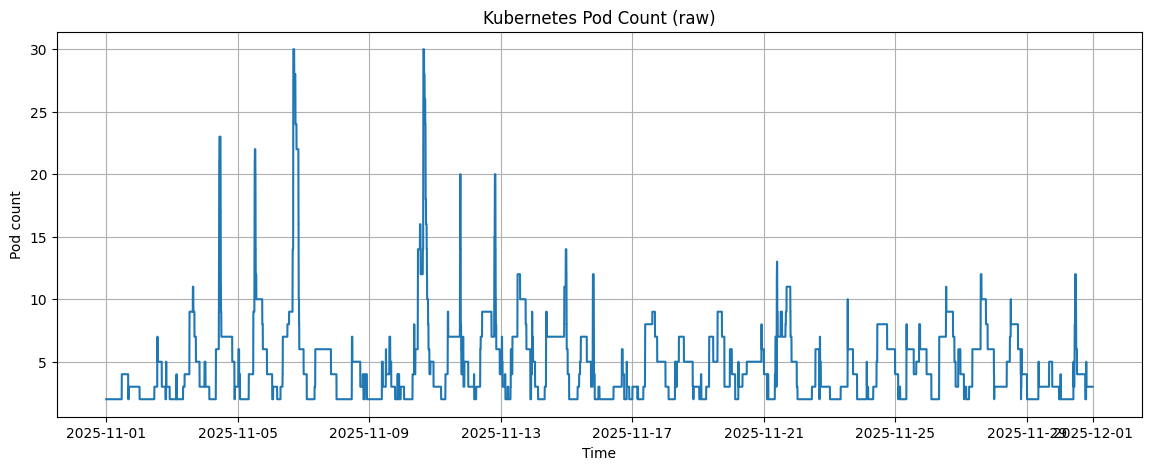

In [11]:
import os

# ensure images directory exists before saving plots
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(14, 5))
plt.plot(df_pods['ds'], df_pods['pod_count'])
plt.title('Kubernetes Pod Count (raw)')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.savefig("images/pods-raw.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Data Splitting & Preprocessing

1. Scale pod count and features to 0-1
2. Split dataset as 70% training, 30% testing (time-ordered)
3. Forward-fill missing values
4. Drop duplicate timestamps

In [12]:
target_scaler = MinMaxScaler(feature_range=(0, 1))
feature_scaler = MinMaxScaler()

df_pods['y'] = target_scaler.fit_transform(df_pods[['pod_count']])
df_pods[feature_cols] = feature_scaler.fit_transform(df_pods[feature_cols])

In [13]:
train_df_pods, test_df_pods = train_test_split(df_pods, test_size=0.3, random_state=42, shuffle=False)

print(f'POD DATASET: Train Set: {train_df_pods.shape} | Test Set: {test_df_pods.shape}')

POD DATASET: Train Set: (30240, 24) | Test Set: (12960, 24)


In [14]:
train_df_pods['y'].fillna(method='ffill', inplace=True)
train_df_pods.drop_duplicates(subset='ds', inplace=True)

print(f'POD DATASET: Train Set: {train_df_pods.shape} | Test Set: {test_df_pods.shape}')

POD DATASET: Train Set: (30240, 24) | Test Set: (12960, 24)


C:\Users\dilee\AppData\Local\Temp\ipykernel_20244\4286280144.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_pods['y'].fillna(method='ffill', inplace=True)
C:\Users\dilee\AppData\Local\Temp\ipykernel_20244\4286280144.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df_pods['y'].fillna(method='ffill', inplace=True)


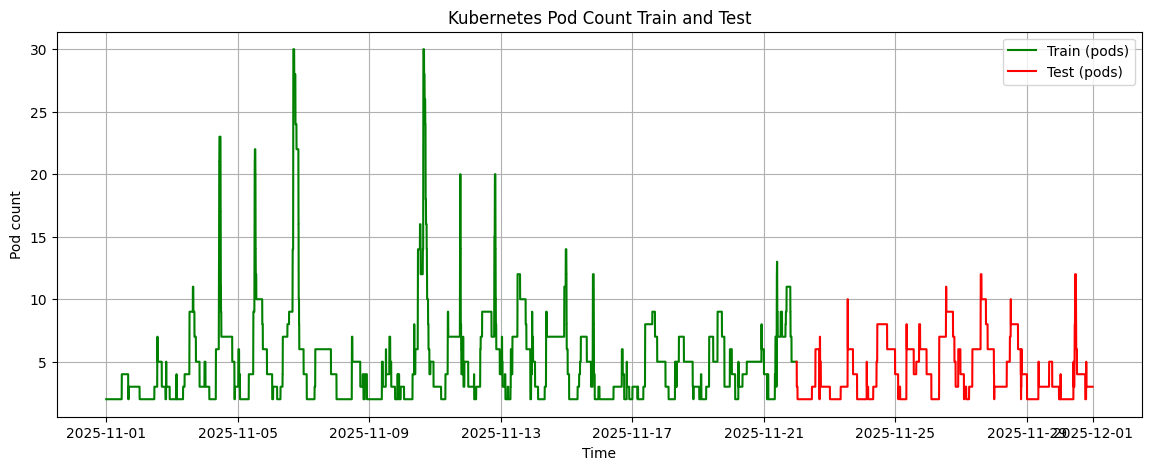

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(train_df_pods['ds'], train_df_pods['pod_count'], label='Train (pods)', color='green')
plt.plot(test_df_pods['ds'], test_df_pods['pod_count'], label='Test (pods)', color='red')
plt.title('Kubernetes Pod Count Train and Test')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.legend()
plt.savefig("images/pods-train-test.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Model Training

## Seasonality Capturing with Prophet

### Train Model

In [16]:
model_one = Prophet(
    growth='flat',
    changepoint_prior_scale=5.1,
    yearly_seasonality=False,
    weekly_seasonality=20,
    daily_seasonality=50,
    seasonality_prior_scale=30
)
model_one.fit(train_df_pods[['ds', 'y']])

00:52:55 - cmdstanpy - INFO - Chain [1] start processing
00:52:57 - cmdstanpy - INFO - Chain [1] done processing


### Predict Dataset

In [17]:
# Use chunked prediction to avoid creating a huge design matrix in memory
def chunked_predict(model, df, chunk_size=5000):
    preds = []
    for i in range(0, len(df), chunk_size):
        chunk = df.iloc[i:i+chunk_size][['ds']].copy()
        preds.append(model.predict(chunk))
    return pd.concat(preds, ignore_index=True)

forecast_train_df_pods = chunked_predict(model_one, train_df_pods, chunk_size=5000)

start_time = time.time()
forecast_test_df_pods = chunked_predict(model_one, test_df_pods, chunk_size=5000)
end_time = time.time()

In [18]:
forecast_test_df_pods_analysis = test_df_pods[['ds', 'y', 'pod_count']].copy()
forecast_test_df_pods_analysis = forecast_test_df_pods_analysis.merge(forecast_test_df_pods[['ds', 'yhat']], on='ds', how='left')
forecast_test_df_pods_analysis['yhat_pods'] = target_scaler.inverse_transform(forecast_test_df_pods_analysis[['yhat']])
forecast_test_df_pods_analysis['y_true_pods'] = forecast_test_df_pods_analysis['pod_count'].values

mse = mean_squared_error(forecast_test_df_pods_analysis['y_true_pods'], forecast_test_df_pods_analysis['yhat_pods'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(forecast_test_df_pods_analysis['y_true_pods'], forecast_test_df_pods_analysis['yhat_pods'])
r2 = r2_score(forecast_test_df_pods_analysis['y_true_pods'], forecast_test_df_pods_analysis['yhat_pods'])
model_one_time = (end_time - start_time) * 1000

print('=== Prophet Baseline (Pod Count) Metrics ===')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'R²: {r2}')
print(f'Prediction Time: {model_one_time}ms')

=== Prophet Baseline (Pod Count) Metrics ===
MSE: 2.2909108876472315
RMSE: 1.5135755308696133
MAE: 1.0672554238204264
R²: 0.5456932761629767
Prediction Time: 1543.5655117034912ms


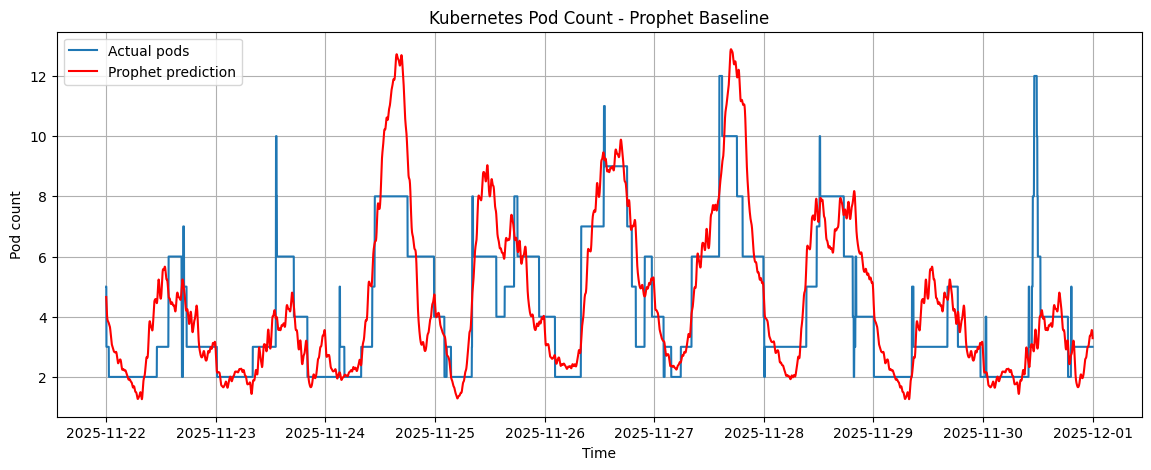

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(test_df_pods['ds'], test_df_pods['pod_count'], label='Actual pods', color='#1f77b4')
plt.plot(forecast_test_df_pods['ds'], target_scaler.inverse_transform(forecast_test_df_pods[['yhat']]), label='Prophet prediction', color='red')
plt.title('Kubernetes Pod Count - Prophet Baseline')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.legend()
plt.savefig("images/pods-prophet-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

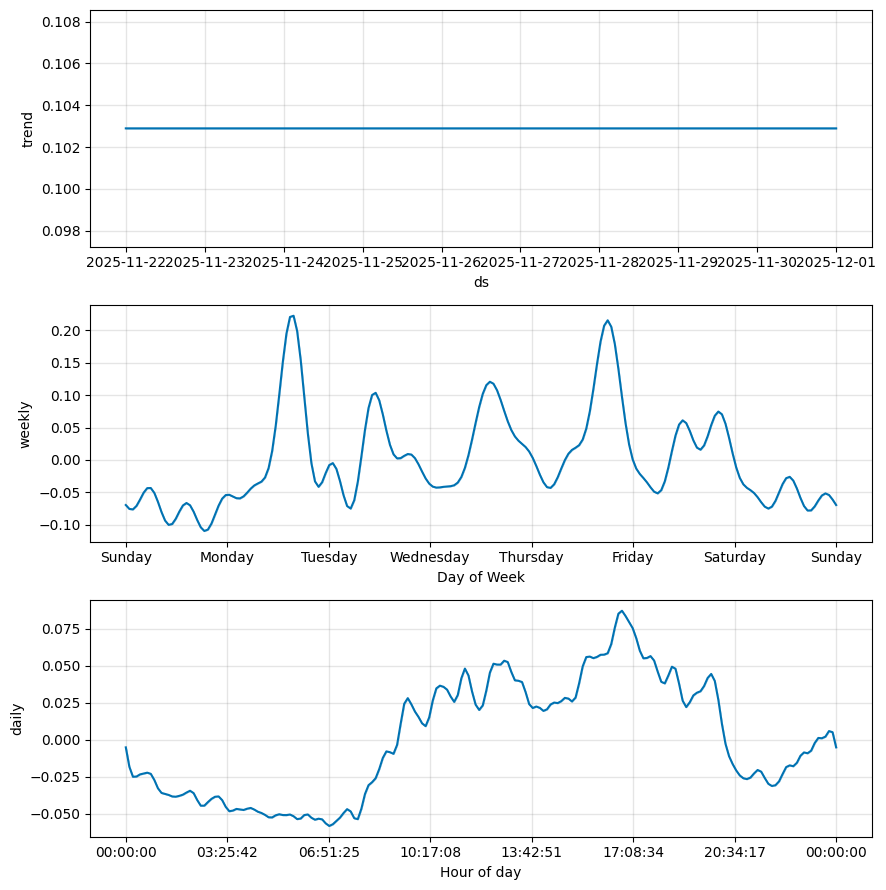

In [20]:
components_fig = model_one.plot_components(forecast_test_df_pods);
ax_weekly = components_fig.get_axes()[1]
ax_daily = components_fig.get_axes()[2]

plt.figure(figsize=(14, 5))
plt.plot(ax_weekly.lines[0].get_xdata(), ax_weekly.lines[0].get_ydata())
plt.title('Weekly Seasonality Component')
plt.xlabel(ax_weekly.get_xlabel())
plt.ylabel(ax_weekly.get_ylabel())
plt.grid(True)
plt.savefig("images/pods-prophet-weekly.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

plt.figure(figsize=(14, 5))
plt.plot(ax_daily.lines[0].get_xdata(), ax_daily.lines[0].get_ydata())
plt.title('Daily Seasonality Component')
plt.xlabel(ax_daily.get_xlabel())
plt.ylabel(ax_daily.get_ylabel())
plt.grid(True)
plt.savefig("images/pods-prophet-daily.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

## Merge Forecasted Data

In [21]:
forecast_df_pods = pd.concat([forecast_train_df_pods, forecast_test_df_pods])

## Residual Analysis

### Calculate Residuals

In [22]:
df_pods_residual = df_pods.merge(forecast_df_pods[['ds', 'yhat']], on='ds', how='left')
df_pods_residual['residual'] = df_pods_residual['y'] - df_pods_residual['yhat']
residual_feature_cols = feature_cols + ['residual']
df_pods_residual.head()

,ds,service_id,pod_count,request_rate_rps,latency_p95_ms,latency_p99_ms,error_rate_percent,queue_length,pod_cpu_usage_percent_avg,pod_cpu_usage_percent_p95,...,mesh_inbound_rps,mesh_inbound_latency_p95,mesh_inbound_error_rate,degree_centrality,eigenvector_centrality,betweenness_centrality,closeness_centrality,y,yhat,residual
0,2025-11-01 00:00:00,Order,2,0.025669,0.132548,0.132659,0.002166,0.0,0.216622,0.194273,...,0.024894,0.140319,0.004167,0.519777,0.343272,0.498200,0.623649,0.0,0.094849,-0.094849
1,2025-11-01 00:01:00,Order,2,0.026770,0.160436,0.177371,0.002216,0.0,0.255984,0.232739,...,0.026105,0.158184,0.002661,0.360168,0.467365,0.603060,0.533013,0.0,0.092530,-0.092530
2,2025-11-01 00:02:00,Order,2,0.028424,0.151352,0.160443,0.002314,0.0,0.251463,0.246894,...,0.028141,0.144103,0.002761,0.415077,0.618856,0.395590,0.464586,0.0,0.090183,-0.090183
3,2025-11-01 00:03:00,Order,2,0.029590,0.131849,0.112843,0.002363,0.0,0.307713,0.288925,...,0.029238,0.137490,0.005472,0.298278,0.578566,0.545005,0.663866,0.0,0.087842,-0.087842
4,2025-11-01 00:04:00,Order,2,0.029548,0.116603,0.103859,0.002363,0.0,0.273537,0.247650,...,0.028339,0.122816,0.004518,0.449977,0.471394,0.527453,0.442977,0.0,0.085537,-0.085537


### Prepare Dataset for LSTM

In [23]:
def create_dataset(features, target, look_back, horizon=60):
    """Create sliding window sequences for horizon forecasting (multivariate)."""
    X, y = [], []
    features = np.array(features)
    target = np.array(target)
    max_idx = len(target) - look_back - horizon + 1
    for i in range(max_idx):
        X.append(features[i:i + look_back, :])
        y.append(target[i + look_back + horizon - 1])
    return np.array(X), np.array(y)

In [24]:
look_back = 48
horizon = 5
X_pods, y_pods = create_dataset(df_pods_residual[residual_feature_cols], df_pods_residual['residual'], look_back, horizon=horizon)

In [25]:
X_train_pods, X_test_pods, y_train_pods, y_test_pods = train_test_split(X_pods, y_pods, test_size=0.3, random_state=42, shuffle=False)

num_features = X_train_pods.shape[2]

print(f'POD DATASET: Train Set: {X_train_pods.shape} | Test Set: {X_test_pods.shape}')

POD DATASET: Train Set: (30203, 48, 21) | Test Set: (12945, 48, 21)


### Model Definition

In [26]:
model_two = None

#### Early Stopping

In [27]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#### HyperParameter Tuning (If Enabled)

In [28]:
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=512, step=32), return_sequences=True, input_shape=(look_back, num_features)))
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=512, step=32), return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=hp.Choice('optimizer', values=['adam', 'rmsprop']), loss='mean_squared_error')
    return model

In [29]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=2,
    directory='hyperparam_tuning',
    project_name='lstm_hyperparam_tuning'
)

c:\Users\dilee\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
if HYPERPARAMETER_TUNING:
    tuner.search(X_train_fifa, y_train_fifa, epochs=50, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=1)

In [31]:
if HYPERPARAMETER_TUNING:
    model_two = tuner.get_best_models(num_models=1)[0]
    model_two_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"Units: {model_two_hyperparameters.get('units')}")
    print(f"Optimizer: {model_two_hyperparameters.get('optimizer')}")

#### Default Model

In [32]:
if not HYPERPARAMETER_TUNING:
    model_two = Sequential()
    model_two.add(LSTM(50, return_sequences=True, input_shape=(look_back, num_features)))
    model_two.add(LSTM(50, return_sequences=False))
    model_two.add(Dense(1))
    model_two.compile(optimizer='adam', loss='mean_squared_error')

Print Model Summery

In [33]:
model_two.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 48, 50)         │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,651 (135.36 KB)

 Trainable params: 34,651 (135.36 KB)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [34]:
model_two.fit(X_train_pods, y_train_pods, epochs=50, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=1)

Epoch 1/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - loss: 9.6631e-04 - val_loss: 3.5085e-04
Epoch 2/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - loss: 4.4206e-04 - val_loss: 2.8354e-04
Epoch 3/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - loss: 3.6619e-04 - val_loss: 2.4622e-04
Epoch 4/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - loss: 3.2064e-04 - val_loss: 2.3539e-04
Epoch 5/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - loss: 2.9411e-04 - val_loss: 2.2799e-04
Epoch 6/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - loss: 2.7708e-04 - val_loss: 2.2471e-04
Epoch 7/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - loss: 2.6472e-04 - val_loss: 2.2462e-04
Epoch 8/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - loss: 2.5471e-04 - val_loss: 2.2072e-04
Epoch 9/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - loss: 2.4907e-04 - val_loss: 2.1985e-04
Epoch 10/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - loss: 2.4417e-04 - val_loss: 2.2662e-04
Epoch 11/50
1511/15

### Predict Dataset

In [35]:
pods_train_predict = model_two.predict(X_train_pods)

start_time = time.time()
pods_test_predict = model_two.predict(X_test_pods)
end_time = time.time()

print(f'POD DATASET - Prediction Size Train: {len(pods_train_predict)} | Prediction Size Test: {len(pods_test_predict)}')

944/944 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
POD DATASET - Prediction Size Train: 30203 | Prediction Size Test: 12945


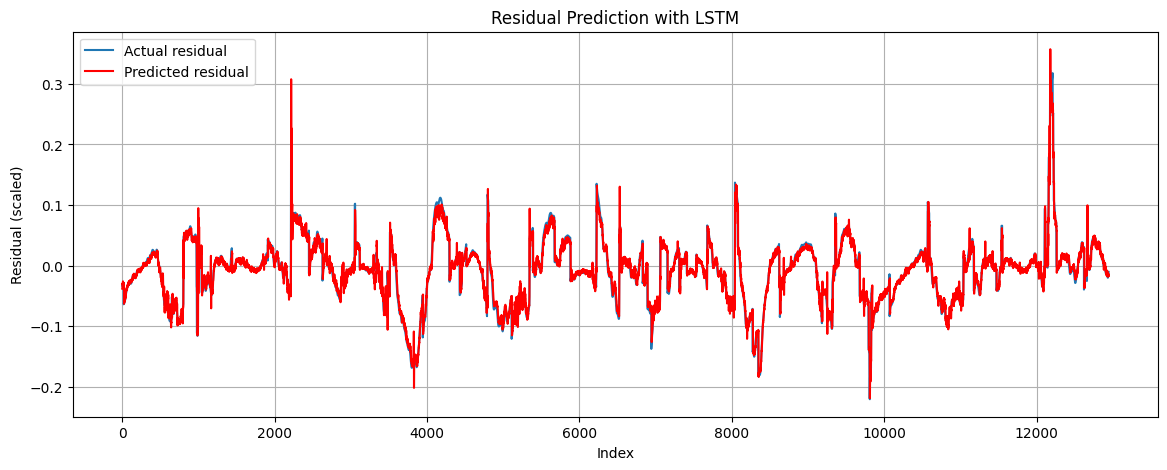

In [36]:
plt.figure(figsize=(14,5))
plt.plot(y_test_pods, label='Actual residual', color='#1f77b4')
plt.plot(pods_test_predict, label='Predicted residual', color='red')
plt.xlabel('Index')
plt.ylabel('Residual (scaled)')
plt.title('Residual Prediction with LSTM')
plt.legend()
plt.grid(True)
plt.savefig("images/pods-lstm-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [37]:
mse = mean_squared_error(y_test_pods, pods_test_predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_pods, pods_test_predict)
r2 = r2_score(y_test_pods, pods_test_predict)
model_two_time = (end_time - start_time) * 1000

print('=== LSTM Residual Model Metrics (scaled residuals) ===')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'R2: {r2}')
print(f'Prediction Time: {model_two_time}ms')

=== LSTM Residual Model Metrics (scaled residuals) ===
MSE: 0.00015994233134491913
RMSE: 0.012646830881486442
MAE: 0.006614528599123571
R2: 0.9435924758699116
Prediction Time: 3293.372631072998ms


## Combine Results from Both Models

In [38]:
pods_combine_predict = np.concatenate((pods_train_predict, pods_test_predict))

final_df_pods = df_pods_residual.copy()

final_df_pods['residual_predict'] = np.nan
final_df_pods.iloc[0:len(pods_combine_predict), final_df_pods.columns.get_loc('residual_predict')] = pods_combine_predict[:, 0]
print(f"POD DATASET: Total Output: {final_df_pods.shape[0]} | Missing residual preds: {final_df_pods['residual_predict'].isna().sum()}")

final_df_pods['residual_predict'] = final_df_pods['residual_predict'].fillna(final_df_pods['residual'])

final_df_pods['y_predicted_scaled'] = final_df_pods['yhat'] + final_df_pods['residual_predict']
final_df_pods['y_true'] = target_scaler.inverse_transform(final_df_pods[['y']])
final_df_pods['y_predicted'] = target_scaler.inverse_transform(final_df_pods[['y_predicted_scaled']])

final_df_pods.head()

POD DATASET: Total Output: 43200 | Missing residual preds: 52


,ds,service_id,pod_count,request_rate_rps,latency_p95_ms,latency_p99_ms,error_rate_percent,queue_length,pod_cpu_usage_percent_avg,pod_cpu_usage_percent_p95,...,eigenvector_centrality,betweenness_centrality,closeness_centrality,y,yhat,residual,residual_predict,y_predicted_scaled,y_true,y_predicted
0,2025-11-01 00:00:00,Order,2,0.025669,0.132548,0.132659,0.002166,0.0,0.216622,0.194273,...,0.343272,0.498200,0.623649,0.0,0.094849,-0.094849,-0.053944,0.040906,2.0,3.145358
1,2025-11-01 00:01:00,Order,2,0.026770,0.160436,0.177371,0.002216,0.0,0.255984,0.232739,...,0.467365,0.603060,0.533013,0.0,0.092530,-0.092530,-0.053763,0.038767,2.0,3.085486
2,2025-11-01 00:02:00,Order,2,0.028424,0.151352,0.160443,0.002314,0.0,0.251463,0.246894,...,0.618856,0.395590,0.464586,0.0,0.090183,-0.090183,-0.053221,0.036963,2.0,3.034957
3,2025-11-01 00:03:00,Order,2,0.029590,0.131849,0.112843,0.002363,0.0,0.307713,0.288925,...,0.578566,0.545005,0.663866,0.0,0.087842,-0.087842,-0.052459,0.035383,2.0,2.990723
4,2025-11-01 00:04:00,Order,2,0.029548,0.116603,0.103859,0.002363,0.0,0.273537,0.247650,...,0.471394,0.527453,0.442977,0.0,0.085537,-0.085537,-0.054391,0.031146,2.0,2.872085


### Extract Test Dataset Related Dataframe & Calculate Metrics

In [39]:
final_df_pods_analysis = final_df_pods.iloc[train_df_pods.shape[0]:]
final_df_pods_analysis.tail()

print(f'POD DATASET: Testing Output: {final_df_pods_analysis.shape}')

POD DATASET: Testing Output: (12960, 30)


In [40]:
mse = mean_squared_error(final_df_pods_analysis['y_true'], final_df_pods_analysis['y_predicted'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(final_df_pods_analysis['y_true'], final_df_pods_analysis['y_predicted'])
r2 = r2_score(final_df_pods_analysis['y_true'], final_df_pods_analysis['y_predicted'])

print('=== Hybrid Model Metrics (Pod Count) ===')
print(f'MSE: {mse:.6f}')
print(f'RMSE: {rmse:.6f}')
print(f'MAE: {mae:.6f}')
print(f'R²: {r2:.6f}')
print(f'Prediction Time: {model_one_time + model_two_time}ms')

=== Hybrid Model Metrics (Pod Count) ===
MSE: 1.512160
RMSE: 1.229699
MAE: 0.779091
R²: 0.700126
Prediction Time: 4836.938142776489ms


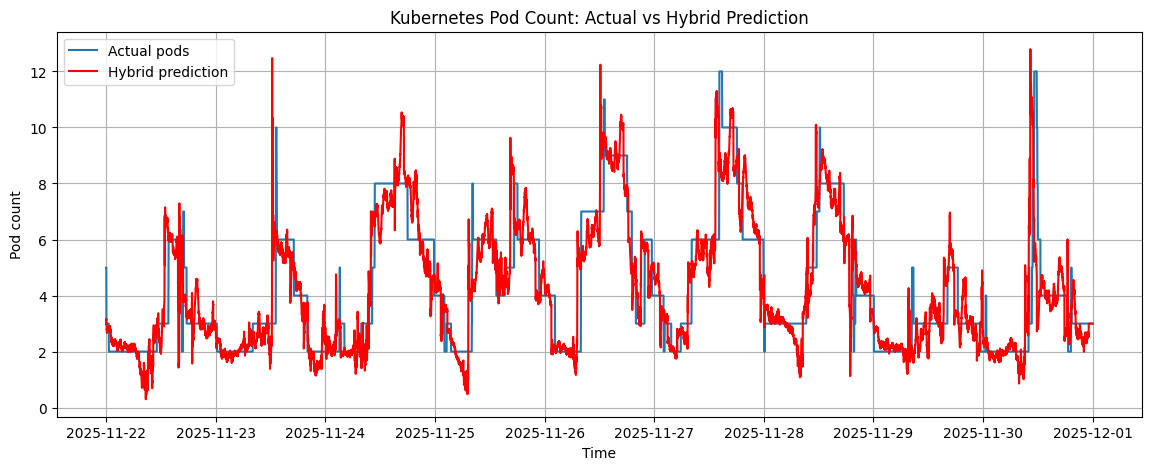

In [41]:
plt.figure(figsize=(14, 5))
plt.plot(test_df_pods['ds'], test_df_pods['pod_count'], label='Actual pods', color='#1f77b4')
plt.plot(final_df_pods_analysis['ds'], final_df_pods_analysis['y_predicted'], label='Hybrid prediction', color='red')
plt.title('Kubernetes Pod Count: Actual vs Hybrid Prediction')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.legend()
plt.savefig("images/pods-final-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## Save Models

In [42]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f'models/fbprophet-pods-{timestamp}.json'
with open(filename, 'w') as fout:
    fout.write(model_to_json(model_one))

filename = f'models/lstm-pods-{timestamp}.keras'
model_two.save(filename)

# SUMMERY


In [43]:
# Elasticity Metrics Computation
def compute_elasticity_metrics(actual, predicted, sample_interval_minutes=1):
    """Compute elasticity metrics for autoscaling evaluation."""
    r_t = np.array(actual, dtype=float)
    p_t = np.array(predicted, dtype=float)

    n = len(r_t)
    total_time_minutes = n * sample_interval_minutes

    under = np.maximum(r_t - p_t, 0.0)
    over = np.maximum(p_t - r_t, 0.0)

    sgn_under = (under > 0).astype(int)
    sgn_over = (over > 0).astype(int)

    # Normalized (%) metrics
    valid = r_t > 0
    r_t_valid = r_t[valid]
    under_valid = under[valid]
    over_valid = over[valid]

    theta_u = (100.0 / total_time_minutes) * float((under_valid / r_t_valid).sum())
    theta_o = (100.0 / total_time_minutes) * float((over_valid / r_t_valid).sum())
    t_u = (100.0 / total_time_minutes) * float(sgn_under.sum())
    t_o = (100.0 / total_time_minutes) * float(sgn_over.sum())

    # ε_n (elastic speed-up)
    constant = 0.189 * 593.755 * 2.2 * 97.6
    if theta_u == 0 or theta_o == 0 or t_u == 0 or t_o == 0:
        elastic_speedup = float('inf')
    else:
        elastic_speedup = float((constant / (theta_u * theta_o * t_u * t_o)) ** 0.25)

    return theta_u, theta_o, t_u, t_o, elastic_speedup

# Use rounded predicted pods (at least 1) for provisioning comparison
actual_pods = final_df_pods_analysis['y_true'].to_numpy()
predicted_pods = np.maximum(np.round(final_df_pods_analysis['y_predicted']).astype(int), 1)

# Compute elasticity metrics
theta_u, theta_o, t_u, t_o, elastic_speedup = compute_elasticity_metrics(
    actual_pods, predicted_pods, sample_interval_minutes=1
)

# Provisioning analysis
under_provisioned = (predicted_pods < actual_pods).sum()
over_provisioned = (predicted_pods > actual_pods).sum()
exact_match = (predicted_pods == actual_pods).sum()
total = len(actual_pods)

# Print Summary
print("=== Elasticity Metrics (Hybrid Prophet+LSTM) ===")
print(f"Θ_U (avg under %): {theta_u:.4f}")
print(f"Θ_O (avg over %):  {theta_o:.4f}")
print(f"T_U (time under %): {t_u:.4f}")
print(f"T_O (time over %):  {t_o:.4f}")
print(f"ε_n (elastic speed-up): {elastic_speedup}")
print()
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R²: {r2:.6f}")
print("-" * 60)
print("PROVISIONING")
print("-" * 60)
print(f"Under-provisioned: {100*under_provisioned/total:.2f}%")
print(f"Over-provisioned: {100*over_provisioned/total:.2f}%")
print(f"Exact match: {100*exact_match/total:.2f}%")

=== Elasticity Metrics (Hybrid Prophet+LSTM) ===
Θ_U (avg under %): 7.6795
Θ_O (avg over %):  10.4314
T_U (time under %): 26.5741
T_O (time over %):  21.0417
ε_n (elastic speed-up): 0.8564115519270261

MSE: 1.512160
RMSE: 1.229699
MAE: 0.779091
R²: 0.700126
------------------------------------------------------------
PROVISIONING
------------------------------------------------------------
Under-provisioned: 26.57%
Over-provisioned: 21.04%
Exact match: 52.38%
